# Pipeline Tessellation AntakIA - Démonstration par Étapes

Ce notebook démontre le pipeline complet de tessellation :

```
┌─────────────────────────────────────────────────────────────────────────────┐
│  ÉTAPE 1       ÉTAPE 2          ÉTAPE 3           ÉTAPE 4       ÉTAPE 5    │
│  ════════      ════════         ════════          ════════      ════════   │
│  Données   →   SHAP Values  →   Interactions  →   Coopétition → Tesselles │
│  + Modèle      (Ordre 1)        (Ordre 2)         (CI)          (Clusters)│
└─────────────────────────────────────────────────────────────────────────────┘
```

**Note** : Toutes les cellules partagent le même kernel → les variables persistent automatiquement.

---
## Configuration et Imports

In [1]:
# Auto-reload pour le développement
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# S'assurer que le module antakia local est dans le path
PROJECT_ROOT = Path().absolute().parent
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print(f"✓ Python {sys.version.split()[0]}")
print(f"✓ NumPy {np.__version__}")
print(f"✓ Source: {SRC_PATH}")

✓ Python 3.11.7
✓ NumPy 1.26.4
✓ Source: /Users/david/Documents/2_Code/artist-maturation/antakia/src


---
## ÉTAPE 1 : Données et Modèle

On utilise California Housing comme exemple réaliste.

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import time

# Charger les données
print("[1/3] Chargement California Housing...")
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = list(housing.feature_names)

# Sous-échantillonner pour la démo (2000 points)
n_samples = 2000
np.random.seed(42)
idx = np.random.choice(len(X), n_samples, replace=False)
X = X[idx]
y = y[idx]

print(f"   • {X.shape[0]} samples, {X.shape[1]} features")
print(f"   • Features: {feature_names}")
print(f"   • Target: Prix médian (en 100k$)")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraîner le modèle
print("\n[2/3] Entraînement RandomForest...")
start = time.time()
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print(f"   • Temps: {time.time()-start:.1f}s")

# Score
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"\n[3/3] Performance:")
print(f"   • R² train: {train_score:.3f}")
print(f"   • R² test:  {test_score:.3f}")

print("\n" + "═"*60)
print("✓ ÉTAPE 1 TERMINÉE - Variables disponibles:")
print("  • X, y (données)")
print("  • model (RandomForestRegressor)")
print("  • feature_names")
print("═"*60)

[1/3] Chargement California Housing...
   • 2000 samples, 8 features
   • Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
   • Target: Prix médian (en 100k$)

[2/3] Entraînement RandomForest...
   • Temps: 0.1s

[3/3] Performance:
   • R² train: 0.932
   • R² test:  0.756

════════════════════════════════════════════════════════════
✓ ÉTAPE 1 TERMINÉE - Variables disponibles:
  • X, y (données)
  • model (RandomForestRegressor)
  • feature_names
════════════════════════════════════════════════════════════


---
## ÉTAPE 2 : Valeurs SHAP (Ordre 1)

Les valeurs SHAP de base expliquent la contribution **individuelle** de chaque feature.

In [3]:
import shap

print(f"SHAP version: {shap.__version__}")
print("\n[1/2] Calcul des valeurs SHAP (ordre 1)...")

start = time.time()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
print(f"   • Temps: {time.time()-start:.1f}s")
print(f"   • Shape: {shap_values.shape}")

# Résumé des contributions moyennes
print("\n[2/2] Contributions moyennes absolues:")
mean_shap = np.abs(shap_values).mean(axis=0)
for name, val in sorted(zip(feature_names, mean_shap), key=lambda x: -x[1]):
    bar = "█" * int(val * 20)
    print(f"   {name:12} {bar} {val:.3f}")

print("\n" + "═"*60)
print("✓ ÉTAPE 2 TERMINÉE - Variables ajoutées:")
print("  • shap_values (n_samples, n_features)")
print("  • explainer (TreeExplainer)")
print("═"*60)

SHAP version: 0.43.0

[1/2] Calcul des valeurs SHAP (ordre 1)...
   • Temps: 8.4s
   • Shape: (2000, 8)

[2/2] Contributions moyennes absolues:
   MedInc       ███████████ 0.562
   AveOccup     ████ 0.235
   Latitude     ███ 0.181
   Longitude    ██ 0.146
   HouseAge     █ 0.085
   AveRooms     █ 0.051
   AveBedrms     0.029
   Population    0.021

════════════════════════════════════════════════════════════
✓ ÉTAPE 2 TERMINÉE - Variables ajoutées:
  • shap_values (n_samples, n_features)
  • explainer (TreeExplainer)
════════════════════════════════════════════════════════════


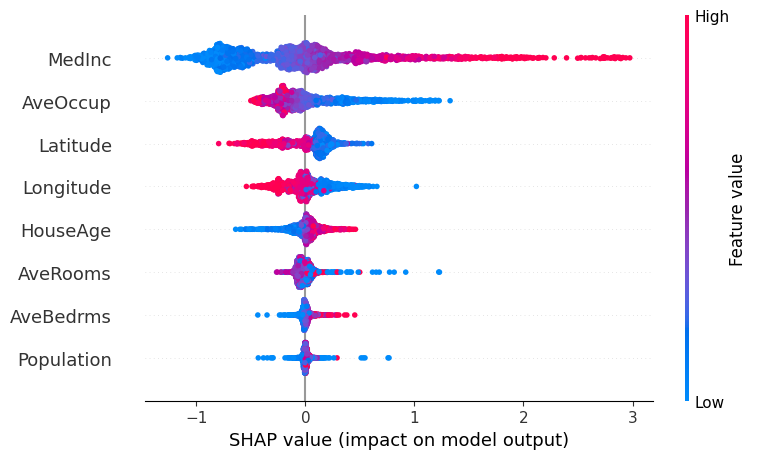

In [4]:
# Visualisation SHAP classique (optionnel)
shap.summary_plot(shap_values, X, feature_names=feature_names, show=True)

---
## ÉTAPE 3 : Interactions de Shapley (Ordre 2)

Les interactions révèlent comment les features influencent **conjointement** la prédiction.

**Principe directeur** : *Là où il y a des interactions fortes, il y a une structure causale.*

In [5]:
from antakia.interactions import (
    compute_shap_interactions_fast,
    plot_interaction_heatmap,
    plot_feature_interaction_scores
)

print("[1/2] Calcul des interactions (SHAP natif - rapide)...")

start = time.time()
interaction_result = compute_shap_interactions_fast(
    model, 
    X,
    n_samples=500,  # Sous-échantillon pour rapidité
    verbose=True
)
elapsed = time.time() - start

print(f"\n   • Temps: {elapsed:.1f}s")
print(f"   • Paires analysées: {len(interaction_result.pairwise)}")

# Top interactions
print("\n[2/2] Top 10 interactions:")
sorted_pairs = sorted(
    interaction_result.pairwise.items(),
    key=lambda x: abs(np.mean(x[1])),
    reverse=True
)[:10]

for (i, j), values in sorted_pairs:
    mean_val = np.mean(values)
    label = "SYNERGIE" if mean_val > 0 else "REDONDANCE"
    print(f"   {feature_names[i]:12} × {feature_names[j]:12}: {mean_val:+.4f} [{label}]")

print("\n" + "═"*60)
print("✓ ÉTAPE 3 TERMINÉE - Variables ajoutées:")
print("  • interaction_result (InteractionResult)")
print("  • interaction_result.pairwise (dict)")
print("  • interaction_result.feature_scores (array)")
print("═"*60)

[1/2] Calcul des interactions (SHAP natif - rapide)...
Calcul interactions SHAP natif (TreeExplainer)
  - 500 observations, 8 features
  - Backend: CPU
  - Temps: 26.80s
  - 2 features problématiques

   • Temps: 26.8s
   • Paires analysées: 28

[2/2] Top 10 interactions:
   Latitude     × Longitude   : -0.0189 [REDONDANCE]
   MedInc       × Longitude   : -0.0106 [REDONDANCE]
   MedInc       × Latitude    : -0.0103 [REDONDANCE]
   MedInc       × AveRooms    : +0.0061 [SYNERGIE]
   MedInc       × AveBedrms   : -0.0044 [REDONDANCE]
   AveOccup     × Latitude    : -0.0030 [REDONDANCE]
   HouseAge     × Latitude    : +0.0024 [SYNERGIE]
   AveRooms     × AveOccup    : +0.0017 [SYNERGIE]
   Population   × AveOccup    : -0.0015 [REDONDANCE]
   AveBedrms    × AveOccup    : +0.0013 [SYNERGIE]

════════════════════════════════════════════════════════════
✓ ÉTAPE 3 TERMINÉE - Variables ajoutées:
  • interaction_result (InteractionResult)
  • interaction_result.pairwise (dict)
  • interaction_resu

In [6]:
# Visualisation heatmap des interactions
fig_heatmap = plot_interaction_heatmap(
    interaction_result,
    feature_names=feature_names,
    title="Matrice des Interactions de Shapley"
)
fig_heatmap.show()

In [7]:
# Score d'interaction par feature
fig_scores = plot_feature_interaction_scores(
    interaction_result,
    feature_names=feature_names,
    title="Score d'Interaction par Feature"
)
fig_scores.show()

---
## ÉTAPE 4 : Indices de Coopétition

Les indices de coopétition quantifient si les interactions sont **coopératives** (synergie) ou **compétitives** (redondance).

**Principe directeur** : *Les coalitions coopératives révèlent des causes latentes communes.*

In [11]:
from antakia.coopetition import (
    compute_coopetition_indices,
    compute_coalition_candidates,
    identify_cooperative_groups,
    plot_coopetition_spectrum,
    plot_cooperative_network
)

print("[1/3] Calcul des indices de coopétition...")

coopetition_result = compute_coopetition_indices(
    interaction_result,
    feature_names=feature_names
)

print(f"   • Features analysées: {len(coopetition_result.ci_raw)}")

# Afficher les CI par feature
print("\n[2/3] Indice de Coopétition par feature:")
for name, ci in sorted(zip(feature_names, coopetition_result.ci_raw), key=lambda x: -x[1]):
    category = coopetition_result.get_feature_category(feature_names.index(name))
    bar = "█" * int(abs(ci) * 30)
    sign = "+" if ci > 0 else "-" if ci < 0 else " "
    print(f"   {name:12} {sign}{bar:20} {ci:+.3f} [{category}]")

# Groupes coopératifs
print("\n[3/3] Groupes coopératifs détectés:")
groups = identify_cooperative_groups(coopetition_result, min_ci_threshold=0.01)
if groups:
    for i, group in enumerate(groups):
        names = [feature_names[idx] for idx in group]
        print(f"   Groupe {i+1}: {names}")
else:
    print("   Aucun groupe fortement coopératif détecté")

# Coalitions candidates
print("\n   Coalitions candidates (pour simplification):")
coalitions = compute_coalition_candidates(coopetition_result, interaction_result, max_coalition_size=3)
for coalition in coalitions[:5]:
    names = [feature_names[idx] for idx in coalition['features']]
    print(f"   • {names} (score: {coalition['score']:.3f})")

print("\n" + "═"*60)
print("✓ ÉTAPE 4 TERMINÉE - Variables ajoutées:")
print("  • coopetition_result (CoopetitionResult)")
print("  • groups (list of cooperative groups)")
print("  • coalitions (list of coalition candidates)")
print("═"*60)

[1/3] Calcul des indices de coopétition...
Indices de Coopétition

Features COOPÉRATIVES (CI > 0):
  AveRooms       : CI = +0.530
  HouseAge       : CI = +0.150

Features COMPÉTITIVES (CI < 0):
  Longitude      : CI = -0.943
  Latitude       : CI = -0.869
  MedInc         : CI = -0.631
  AveBedrms      : CI = -0.447
  AveOccup       : CI = -0.415

Paires coopératives: 0
Paires compétitives: 3
   • Features analysées: 8

[2/3] Indice de Coopétition par feature:
   AveRooms     +                     +0.006 [COOPÉRATIF]
   HouseAge     +                     +0.001 [COOPÉRATIF]
   Population   -                     -0.001 [COMPÉTITIF]
   AveBedrms    -                     -0.003 [COMPÉTITIF]
   AveOccup     -                     -0.004 [COMPÉTITIF]
   MedInc       -                     -0.021 [COMPÉTITIF]
   Longitude    -                     -0.031 [COMPÉTITIF]
   Latitude     -                     -0.032 [COMPÉTITIF]

[3/3] Groupes coopératifs détectés:
   Aucun groupe fortement coopérat

In [14]:
# Spectre de coopétition
fig_spectrum = plot_coopetition_spectrum(
    coopetition_result,
    title="Spectre de Coopétition"
)
fig_spectrum.show()

In [15]:
# Réseau des features coopératives
fig_network = plot_cooperative_network(
    coopetition_result,
    min_edge_weight=0.005
)
fig_network.show()

---
## ÉTAPE 5 : Clustering Dyadique (Tessellation)

Le clustering dyadique cherche des régions cohérentes dans **deux espaces** :
- **VS** (Values Space) : les features originales X
- **ES** (Explanations Space) : les valeurs SHAP

**Principe directeur** : *Une Tesselle pure est une région causalement homogène où f(x) ≈ Σ gᵢ(xᵢ).*

In [16]:
from antakia.clustering import (
    DyadicClusterer,
    cluster_dyadic,
    dyadic_cohesion_score,
    tesselle_quality_report
)

print("[1/3] Clustering dyadique (stratégie: early fusion)...")

# VS = features originales, ES = valeurs SHAP
X_vs = X
X_es = shap_values

start = time.time()
tessellation_result = cluster_dyadic(
    X_vs, 
    X_es,
    strategy='early',
    merge_threshold=0.15,
    min_cluster_size=30
)
print(f"   • Temps: {time.time()-start:.1f}s")
print(f"   • Tesselles trouvées: {tessellation_result.n_clusters}")
print(f"   • Bruit: {tessellation_result.metadata.get('noise_ratio', 0)*100:.1f}%")

# Tailles des clusters
print("\n[2/3] Taille des Tesselles:")
sizes = tessellation_result.get_cluster_sizes()
for cluster_id, size in sorted(sizes.items(), key=lambda x: -x[1]):
    pct = size / len(X) * 100
    bar = "█" * int(pct / 2)
    print(f"   Tesselle {cluster_id}: {bar:25} {size:4d} ({pct:.1f}%)")

# Score dyadique
print("\n[3/3] Qualité dyadique:")
print(f"   • Score dyadique global: {tessellation_result.dyadic_score:.3f}")
print(f"   • Cohésion VS: {tessellation_result.cohesion_vs:.3f}")
print(f"   • Cohésion ES: {tessellation_result.cohesion_es:.3f}")

print("\n" + "═"*60)
print("✓ ÉTAPE 5 TERMINÉE - Variables ajoutées:")
print("  • tessellation_result (DyadicClusteringResult)")
print("  • tessellation_result.labels (cluster assignments)")
print("═"*60)

[1/3] Clustering dyadique (stratégie: early fusion)...
   • Temps: 0.6s
   • Tesselles trouvées: 5
   • Bruit: 0.0%

[2/3] Taille des Tesselles:
   Tesselle 2: ████████████████           643 (32.1%)
   Tesselle 0: ███████████████            600 (30.0%)
   Tesselle 1: ██████                     258 (12.9%)
   Tesselle 4: ██████                     256 (12.8%)
   Tesselle 3: ██████                     243 (12.2%)

[3/3] Qualité dyadique:
   • Score dyadique global: 0.088
   • Cohésion VS: 0.066
   • Cohésion ES: 0.132

════════════════════════════════════════════════════════════
✓ ÉTAPE 5 TERMINÉE - Variables ajoutées:
  • tessellation_result (DyadicClusteringResult)
  • tessellation_result.labels (cluster assignments)
════════════════════════════════════════════════════════════


In [17]:
# Rapport de qualité détaillé
report = tesselle_quality_report(X_vs, X_es, tessellation_result.labels)

print("\n" + "="*60)
print("RAPPORT DE QUALITÉ DES TESSELLES")
print("="*60)
print(f"\nNombre de Tesselles: {report['n_tesselles']}")
print(f"Échantillons total: {report['n_samples']}")
print(f"Ratio de bruit: {report['noise_ratio']*100:.1f}%")
print(f"\nScore de cohésion dyadique: {report['dyadic_cohesion']:.3f}")

print("\nSilhouette scores:")
print(f"  VS (features):     {report['silhouette']['vs']:.3f}")
print(f"  ES (SHAP):         {report['silhouette']['es']:.3f}")
print(f"  Combiné:           {report['silhouette']['combined']:.3f}")

print("\nSéparation (Davies-Bouldin, plus bas = mieux):")
print(f"  VS: {report['separation']['vs']:.3f}")
print(f"  ES: {report['separation']['es']:.3f}")

print("\nPureté par Tesselle:")
print(f"{'Tesselle':^10} {'Taille':^8} {'Pureté VS':^12} {'Pureté ES':^12}")
print("-" * 44)
for cluster_id, metrics in report['purity_per_cluster'].items():
    print(f"{cluster_id:^10} {metrics['size']:^8} {metrics['vs']:^12.3f} {metrics['es']:^12.3f}")


RAPPORT DE QUALITÉ DES TESSELLES

Nombre de Tesselles: 5
Échantillons total: 2000
Ratio de bruit: 0.0%

Score de cohésion dyadique: 0.480

Silhouette scores:
  VS (features):     -0.123
  ES (SHAP):         0.031
  Combiné:           0.105

Séparation (Davies-Bouldin, plus bas = mieux):
  VS: 109.393
  ES: 2.644

Pureté par Tesselle:
 Tesselle   Taille   Pureté VS    Pureté ES  
--------------------------------------------
    0        600       0.238        0.586    
    1        258       0.166        0.142    
    2        643       0.000        0.000    
    3        243       0.032        0.587    
    4        256       0.204        0.772    


---
## ÉTAPE 6 : Visualisation des Tesselles

Projection 2D des Tesselles pour visualiser la séparation.

In [18]:
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# PCA pour visualisation
pca_vs = PCA(n_components=2).fit_transform(X_vs)
pca_es = PCA(n_components=2).fit_transform(X_es)

# DataFrame pour plotly
df_viz = pd.DataFrame({
    'VS_PC1': pca_vs[:, 0],
    'VS_PC2': pca_vs[:, 1],
    'ES_PC1': pca_es[:, 0],
    'ES_PC2': pca_es[:, 1],
    'Tesselle': tessellation_result.labels.astype(str),
    'Prix': y
})

# Marquer le bruit
df_viz.loc[df_viz['Tesselle'] == '-1', 'Tesselle'] = 'Bruit'

# Figure avec 2 sous-plots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Values Space (VS)', 'Explanations Space (ES)']
)

# Couleurs par tesselle
colors = px.colors.qualitative.Set1
tesselles = sorted(df_viz['Tesselle'].unique())

for i, tesselle in enumerate(tesselles):
    mask = df_viz['Tesselle'] == tesselle
    color = 'lightgray' if tesselle == 'Bruit' else colors[i % len(colors)]
    
    # VS
    fig.add_trace(
        go.Scatter(
            x=df_viz.loc[mask, 'VS_PC1'],
            y=df_viz.loc[mask, 'VS_PC2'],
            mode='markers',
            marker=dict(size=5, color=color, opacity=0.6),
            name=f'T{tesselle}',
            legendgroup=tesselle,
            showlegend=True
        ),
        row=1, col=1
    )
    
    # ES
    fig.add_trace(
        go.Scatter(
            x=df_viz.loc[mask, 'ES_PC1'],
            y=df_viz.loc[mask, 'ES_PC2'],
            mode='markers',
            marker=dict(size=5, color=color, opacity=0.6),
            name=f'T{tesselle}',
            legendgroup=tesselle,
            showlegend=False
        ),
        row=1, col=2
    )

fig.update_layout(
    title='Tesselles dans les Deux Espaces (PCA)',
    height=500,
    width=1000
)
fig.show()

### Visualisation UMAP (préservation structure locale)

UMAP est une méthode de réduction de dimension qui préserve bien la structure locale des données.

In [24]:
import umap

print("Calcul UMAP (peut prendre quelques secondes)...")

# UMAP pour VS et ES
umap_model_vs = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_model_es = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)

umap_vs = umap_model_vs.fit_transform(X_vs)
umap_es = umap_model_es.fit_transform(X_es)

# DataFrame pour plotly
df_umap = pd.DataFrame({
    'VS_U1': umap_vs[:, 0],
    'VS_U2': umap_vs[:, 1],
    'ES_U1': umap_es[:, 0],
    'ES_U2': umap_es[:, 1],
    'Tesselle': tessellation_result.labels.astype(str),
    'Prix': y
})
df_umap.loc[df_umap['Tesselle'] == '-1', 'Tesselle'] = 'Bruit'

# Figure UMAP
fig_umap = make_subplots(
    rows=1, cols=2,
    subplot_titles=['VS (UMAP)', 'ES (UMAP)']
)

colors = px.colors.qualitative.Set1
tesselles = sorted(df_umap['Tesselle'].unique())

for i, tesselle in enumerate(tesselles):
    mask = df_umap['Tesselle'] == tesselle
    color = 'lightgray' if tesselle == 'Bruit' else colors[i % len(colors)]
    
    fig_umap.add_trace(
        go.Scatter(
            x=df_umap.loc[mask, 'VS_U1'],
            y=df_umap.loc[mask, 'VS_U2'],
            mode='markers',
            marker=dict(size=5, color=color, opacity=0.6),
            name=f'T{tesselle}',
            legendgroup=tesselle,
            showlegend=True
        ),
        row=1, col=1
    )
    
    fig_umap.add_trace(
        go.Scatter(
            x=df_umap.loc[mask, 'ES_U1'],
            y=df_umap.loc[mask, 'ES_U2'],
            mode='markers',
            marker=dict(size=5, color=color, opacity=0.6),
            name=f'T{tesselle}',
            legendgroup=tesselle,
            showlegend=False
        ),
        row=1, col=2
    )

fig_umap.update_layout(
    title='Tesselles - Projection UMAP (préservation structure locale)',
    height=500,
    width=1000
)
fig_umap.show()
print("✓ UMAP terminé")

Calcul UMAP (peut prendre quelques secondes)...


✓ UMAP terminé


### Visualisation Géographique (si Latitude/Longitude détectées)

Si le dataset contient des coordonnées géographiques, on peut visualiser les Tesselles sur une carte.

In [22]:
# Détection automatique des coordonnées géographiques
def detect_geo_columns(feature_names):
    """Détecte les colonnes latitude et longitude."""
    lat_keywords = ['lat', 'latitude', 'y_coord', 'lat_']
    lon_keywords = ['lon', 'long', 'longitude', 'x_coord', 'lng']
    
    lat_idx, lon_idx = None, None
    
    for i, name in enumerate(feature_names):
        name_lower = name.lower()
        if any(k in name_lower for k in lat_keywords):
            lat_idx = i
        if any(k in name_lower for k in lon_keywords):
            lon_idx = i
    
    return lat_idx, lon_idx

lat_idx, lon_idx = detect_geo_columns(feature_names)

if lat_idx is not None and lon_idx is not None:
    print(f"✓ Coordonnées géographiques détectées:")
    print(f"  • Latitude: {feature_names[lat_idx]} (index {lat_idx})")
    print(f"  • Longitude: {feature_names[lon_idx]} (index {lon_idx})")
    
    # Créer le DataFrame géo
    df_geo = pd.DataFrame({
        'lat': X[:, lat_idx],
        'lon': X[:, lon_idx],
        'Tesselle': tessellation_result.labels.astype(str),
        'Prix': y,
        'SHAP_lat': shap_values[:, lat_idx],
        'SHAP_lon': shap_values[:, lon_idx]
    })
    df_geo.loc[df_geo['Tesselle'] == '-1', 'Tesselle'] = 'Bruit'
    
    # Carte avec Plotly (scatter_mapbox nécessite un token, on utilise scatter_geo)
    fig_geo = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "scattergeo"}, {"type": "scattergeo"}]],
        subplot_titles=['Tesselles (Espace Géographique)', 'SHAP Latitude (intensité)']
    )
    
    colors = px.colors.qualitative.Set1
    tesselles = sorted(df_geo['Tesselle'].unique())
    
    # Carte des Tesselles
    for i, tesselle in enumerate(tesselles):
        mask = df_geo['Tesselle'] == tesselle
        color = 'lightgray' if tesselle == 'Bruit' else colors[i % len(colors)]
        
        fig_geo.add_trace(
            go.Scattergeo(
                lon=df_geo.loc[mask, 'lon'],
                lat=df_geo.loc[mask, 'lat'],
                mode='markers',
                marker=dict(size=4, color=color, opacity=0.6),
                name=f'T{tesselle}',
                legendgroup=tesselle,
                showlegend=True
            ),
            row=1, col=1
        )
    
    # Carte SHAP Latitude (contribution de la position)
    fig_geo.add_trace(
        go.Scattergeo(
            lon=df_geo['lon'],
            lat=df_geo['lat'],
            mode='markers',
            marker=dict(
                size=5,
                color=df_geo['SHAP_lat'],
                colorscale='RdBu_r',
                cmin=-df_geo['SHAP_lat'].abs().max(),
                cmax=df_geo['SHAP_lat'].abs().max(),
                colorbar=dict(title='SHAP<br>Latitude', x=1.02)
            ),
            showlegend=False
        ),
        row=1, col=2
    )
    
    # Centrer sur la Californie (ajuster selon vos données)
    center_lat = df_geo['lat'].mean()
    center_lon = df_geo['lon'].mean()
    
    fig_geo.update_geos(
        scope='usa',
        showland=True,
        landcolor='rgb(243, 243, 243)',
        countrycolor='rgb(204, 204, 204)',
        center=dict(lat=center_lat, lon=center_lon),
        projection_scale=2.5
    )
    
    fig_geo.update_layout(
        title='Visualisation Géographique des Tesselles',
        height=500,
        width=1100
    )
    
    fig_geo.show()
    print("✓ Carte géographique générée")
else:
    print("ℹ Pas de coordonnées géographiques détectées dans ce dataset.")
    print(f"  Features disponibles: {feature_names}")

✓ Coordonnées géographiques détectées:
  • Latitude: Latitude (index 6)
  • Longitude: Longitude (index 7)


✓ Carte géographique générée


### Visualisation Interactive (Sélection Lasso ES ↔ Carte Géo)

Sélectionnez des points dans l'espace ES (gauche) avec l'outil lasso pour voir leur position géographique (droite).

In [26]:
# Visualisation interactive avec sélection lasso synchronisée
# Note: La synchronisation complète nécessite Dash ou ipywidgets pour le callback
# Ici, version statique avec FigureWidget pour exploration

if lat_idx is not None and lon_idx is not None:
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    
    # Créer une figure combinée ES + Carte
    fig_interactive = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "scatter"}, {"type": "scattergeo"}]],
        subplot_titles=['Espace Explications (ES) - Sélection Lasso', 'Position Géographique'],
        horizontal_spacing=0.05
    )
    
    # Utiliser UMAP pour ES (déjà calculé)
    colors_map = px.colors.qualitative.Set1
    tesselles = sorted(df_umap['Tesselle'].unique())
    
    for i, tesselle in enumerate(tesselles):
        mask = df_umap['Tesselle'] == tesselle
        color = 'lightgray' if tesselle == 'Bruit' else colors_map[i % len(colors_map)]
        
        # ES (UMAP)
        fig_interactive.add_trace(
            go.Scatter(
                x=df_umap.loc[mask, 'ES_U1'],
                y=df_umap.loc[mask, 'ES_U2'],
                mode='markers',
                marker=dict(size=6, color=color, opacity=0.7),
                name=f'T{tesselle}',
                legendgroup=tesselle,
                showlegend=True,
                selectedpoints=[],
                selected=dict(marker=dict(color='red', size=10)),
                unselected=dict(marker=dict(opacity=0.3)),
                customdata=np.column_stack([
                    X[:, lat_idx][mask.values],
                    X[:, lon_idx][mask.values],
                    y[mask.values]
                ]),
                hovertemplate="<b>Tesselle %{text}</b><br>Lat: %{customdata[0]:.2f}<br>Lon: %{customdata[1]:.2f}<br>Prix: $%{customdata[2]:.0f}k<extra></extra>",
                text=[tesselle] * mask.sum()
            ),
            row=1, col=1
        )
        
        # Carte Géo
        fig_interactive.add_trace(
            go.Scattergeo(
                lon=X[:, lon_idx][mask.values],
                lat=X[:, lat_idx][mask.values],
                mode='markers',
                marker=dict(size=5, color=color, opacity=0.6),
                name=f'T{tesselle}',
                legendgroup=tesselle,
                showlegend=False,
                hovertemplate="<b>Tesselle %{text}</b><br>Prix: $%{customdata:.0f}k<extra></extra>",
                customdata=y[mask.values],
                text=[tesselle] * mask.sum()
            ),
            row=1, col=2
        )
    
    # Configuration de la carte
    fig_interactive.update_geos(
        scope='usa',
        showland=True,
        landcolor='rgb(243, 243, 243)',
        countrycolor='rgb(204, 204, 204)',
        center=dict(lat=X[:, lat_idx].mean(), lon=X[:, lon_idx].mean()),
        projection_scale=2.5
    )
    
    fig_interactive.update_layout(
        title='<b>Exploration Dyadique Interactive</b><br><sup>Utilisez l\'outil Lasso (en haut à droite) pour sélectionner des points dans ES</sup>',
        height=550,
        width=1200,
        dragmode='lasso',  # Activer le lasso par défaut
        legend=dict(orientation='h', yanchor='bottom', y=1.02)
    )
    
    fig_interactive.show()
    
    print("\\n💡 Astuce: Utilisez l'outil Lasso dans la barre d'outils pour sélectionner des points.")
    print("   Les points sélectionnés seront mis en surbrillance.")
    print("   (Pour une synchronisation complète ES↔Géo, utiliser Dash ou AntakIA GUI)")
else:
    print("ℹ Visualisation interactive non disponible (pas de coordonnées géographiques)")

\n💡 Astuce: Utilisez l'outil Lasso dans la barre d'outils pour sélectionner des points.
   Les points sélectionnés seront mis en surbrillance.
   (Pour une synchronisation complète ES↔Géo, utiliser Dash ou AntakIA GUI)


### Sélection Synchronisée ES ↔ Carte (avec callbacks)

**Vraie synchronisation** : sélectionnez des points dans ES et voyez-les apparaître en rouge sur la carte.

In [27]:
# Visualisation interactive avec sélection SYNCHRONISÉE (FigureWidget + callbacks)
# La sélection dans ES se reflète en temps réel sur la carte géographique

if lat_idx is not None and lon_idx is not None:
    import plotly.graph_objects as go
    from IPython.display import display, clear_output
    import ipywidgets as widgets
    
    # Préparer les données globales (tous les points)
    all_es_x = umap_es[:, 0]
    all_es_y = umap_es[:, 1]
    all_lat = X[:, lat_idx]
    all_lon = X[:, lon_idx]
    all_labels = tessellation_result.labels
    all_prices = y
    
    # Couleurs par tesselle
    colors_map = px.colors.qualitative.Set1
    unique_labels = sorted(set(all_labels))
    label_to_color = {label: 'lightgray' if label == -1 else colors_map[i % len(colors_map)] 
                      for i, label in enumerate(unique_labels)}
    point_colors = [label_to_color[l] for l in all_labels]
    
    # === FIGURE ES (avec FigureWidget pour interactivité) ===
    fig_es = go.FigureWidget()
    
    scatter_es = go.Scatter(
        x=all_es_x,
        y=all_es_y,
        mode='markers',
        marker=dict(
            size=6,
            color=point_colors,
            opacity=0.7,
            line=dict(width=0)
        ),
        text=[f"T{l}" for l in all_labels],
        customdata=np.column_stack([all_lat, all_lon, all_prices, np.arange(len(all_lat))]),
        hovertemplate="<b>Tesselle %{text}</b><br>Index: %{customdata[3]:.0f}<br>Prix: $%{customdata[2]:.0f}k<extra></extra>",
        selected=dict(marker=dict(color='red', size=10, opacity=1)),
        unselected=dict(marker=dict(opacity=0.2)),
        name='Points'
    )
    fig_es.add_trace(scatter_es)
    
    fig_es.update_layout(
        title='<b>Espace Explications (ES)</b><br><sup>🎯 Sélectionnez avec Lasso/Box</sup>',
        xaxis_title='UMAP 1',
        yaxis_title='UMAP 2',
        height=450,
        width=550,
        dragmode='lasso',
        margin=dict(t=80)
    )
    
    # === FIGURE CARTE (FigureWidget pour mise à jour dynamique) ===
    fig_geo = go.FigureWidget()
    
    # Trace de fond (tous les points, gris)
    scatter_geo_bg = go.Scattergeo(
        lon=all_lon,
        lat=all_lat,
        mode='markers',
        marker=dict(size=4, color='lightgray', opacity=0.3),
        hoverinfo='skip',
        name='Tous'
    )
    fig_geo.add_trace(scatter_geo_bg)
    
    # Trace des points sélectionnés (vide au début)
    scatter_geo_selected = go.Scattergeo(
        lon=[],
        lat=[],
        mode='markers',
        marker=dict(size=8, color='red', opacity=0.9, symbol='circle'),
        text=[],
        hovertemplate="<b>Sélection</b><br>Prix: $%{customdata:.0f}k<extra></extra>",
        customdata=[],
        name='Sélection'
    )
    fig_geo.add_trace(scatter_geo_selected)
    
    fig_geo.update_geos(
        scope='usa',
        showland=True,
        landcolor='rgb(243, 243, 243)',
        countrycolor='rgb(204, 204, 204)',
        center=dict(lat=all_lat.mean(), lon=all_lon.mean()),
        projection_scale=2.5
    )
    
    fig_geo.update_layout(
        title='<b>Position Géographique</b><br><sup>🔴 Points sélectionnés dans ES</sup>',
        height=450,
        width=550,
        margin=dict(t=80)
    )
    
    # === INFO WIDGET ===
    info_output = widgets.Output()
    
    # === CALLBACK DE SÉLECTION ===
    def on_selection(trace, points, state):
        """Callback appelé quand des points sont sélectionnés dans ES."""
        with info_output:
            clear_output(wait=True)
            
            if points.point_inds:
                selected_indices = list(points.point_inds)
                n_selected = len(selected_indices)
                
                # Mettre à jour la carte avec les points sélectionnés
                with fig_geo.batch_update():
                    fig_geo.data[1].lon = all_lon[selected_indices]
                    fig_geo.data[1].lat = all_lat[selected_indices]
                    fig_geo.data[1].customdata = all_prices[selected_indices]
                
                # Stats sur la sélection
                selected_prices = all_prices[selected_indices]
                selected_labels = all_labels[selected_indices]
                
                print(f"✅ {n_selected} points sélectionnés")
                print(f"   Prix moyen: ${selected_prices.mean()*100:.0f}k")
                print(f"   Prix min/max: ${selected_prices.min()*100:.0f}k - ${selected_prices.max()*100:.0f}k")
                
                # Répartition par tesselle
                from collections import Counter
                tesselle_counts = Counter(selected_labels)
                print(f"   Tesselles: {dict(tesselle_counts)}")
            else:
                # Aucune sélection - réinitialiser
                with fig_geo.batch_update():
                    fig_geo.data[1].lon = []
                    fig_geo.data[1].lat = []
                    fig_geo.data[1].customdata = []
                print("ℹ️ Aucune sélection. Utilisez Lasso ou Box dans ES.")
    
    # Connecter le callback
    fig_es.data[0].on_selection(on_selection)
    
    # === AFFICHAGE ===
    print("═" * 70)
    print("VISUALISATION INTERACTIVE SYNCHRONISÉE")
    print("═" * 70)
    print("🎯 Sélectionnez des points dans ES (gauche) avec Lasso/Box")
    print("   → Les points apparaissent en rouge sur la carte (droite)")
    print("═" * 70)
    
    # Layout horizontal
    display(widgets.HBox([fig_es, fig_geo]))
    display(info_output)
    
    # Message initial
    with info_output:
        print("ℹ️ En attente de sélection... Utilisez l'outil Lasso dans ES.")

else:
    print("ℹ Visualisation interactive non disponible (pas de coordonnées géographiques)")

NameError: name 'clustering_result' is not defined

---
## ÉTAPE 7 : Analyse par Tesselle

Pour chaque Tesselle, on peut analyser :
- Les statistiques des features
- Les contributions SHAP moyennes
- Le prix moyen prédit

In [25]:
print("\n" + "="*70)
print("ANALYSE DÉTAILLÉE PAR TESSELLE")
print("="*70)

for cluster_id in sorted(set(tessellation_result.labels) - {-1}):
    mask = tessellation_result.labels == cluster_id
    n_points = mask.sum()
    
    print(f"\n{'─'*70}")
    print(f"TESSELLE {cluster_id} ({n_points} points, {n_points/len(X)*100:.1f}%)")
    print(f"{'─'*70}")
    
    # Prix moyen
    prix_moyen = y[mask].mean()
    prix_std = y[mask].std()
    print(f"\nPrix moyen: ${prix_moyen*100:.0f}k ± ${prix_std*100:.0f}k")
    
    # Features dominantes (écart à la moyenne globale)
    print("\nCaractéristiques distinctives:")
    global_means = X.mean(axis=0)
    global_stds = X.std(axis=0)
    cluster_means = X[mask].mean(axis=0)
    
    z_scores = (cluster_means - global_means) / (global_stds + 1e-10)
    sorted_features = sorted(zip(feature_names, z_scores, cluster_means), key=lambda x: -abs(x[1]))
    
    for name, z, mean in sorted_features[:4]:
        direction = "↑" if z > 0 else "↓"
        print(f"  {direction} {name}: {mean:.2f} (z={z:+.2f})")
    
    # SHAP dominants
    print("\nContributions SHAP moyennes:")
    shap_means = shap_values[mask].mean(axis=0)
    sorted_shap = sorted(zip(feature_names, shap_means), key=lambda x: -abs(x[1]))
    
    for name, shap_val in sorted_shap[:3]:
        direction = "+" if shap_val > 0 else ""
        print(f"  {name}: {direction}{shap_val:.3f}")


ANALYSE DÉTAILLÉE PAR TESSELLE

──────────────────────────────────────────────────────────────────────
TESSELLE 0 (600 points, 30.0%)
──────────────────────────────────────────────────────────────────────

Prix moyen: $127k ± $67k

Caractéristiques distinctives:
  ↑ Latitude: 37.95 (z=+1.10)
  ↓ Longitude: -121.26 (z=-0.87)
  ↓ MedInc: 2.91 (z=-0.48)
  ↓ Population: 1209.14 (z=-0.19)

Contributions SHAP moyennes:
  MedInc: -0.432
  Latitude: -0.278
  Longitude: +0.072

──────────────────────────────────────────────────────────────────────
TESSELLE 1 (258 points, 12.9%)
──────────────────────────────────────────────────────────────────────

Prix moyen: $319k ± $96k

Caractéristiques distinctives:
  ↓ Longitude: -122.15 (z=-1.32)
  ↑ Latitude: 37.55 (z=+0.92)
  ↑ MedInc: 5.07 (z=+0.62)
  ↑ HouseAge: 35.02 (z=+0.50)

Contributions SHAP moyennes:
  MedInc: +0.615
  Longitude: +0.271
  AveOccup: +0.096

──────────────────────────────────────────────────────────────────────
TESSELLE 2 (643 

---
## Résumé du Pipeline

Variables créées et disponibles pour la suite :

In [20]:
print("\n" + "═"*70)
print("RÉSUMÉ DU PIPELINE - VARIABLES DISPONIBLES")
print("═"*70)

pipeline_vars = {
    "ÉTAPE 1 - Données": [
        ("X", X.shape, "Features originales"),
        ("y", y.shape, "Target (prix)"),
        ("model", type(model).__name__, "Modèle entraîné"),
        ("feature_names", len(feature_names), "Noms des features"),
    ],
    "ÉTAPE 2 - SHAP": [
        ("shap_values", shap_values.shape, "Valeurs SHAP ordre 1"),
        ("explainer", type(explainer).__name__, "TreeExplainer"),
    ],
    "ÉTAPE 3 - Interactions": [
        ("interaction_result", type(interaction_result).__name__, "Résultat interactions"),
        ("interaction_result.pairwise", len(interaction_result.pairwise), "Paires analysées"),
    ],
    "ÉTAPE 4 - Coopétition": [
        ("coopetition_result", type(coopetition_result).__name__, "Indices CI"),
        ("coalitions", len(coalitions), "Coalitions candidates"),
    ],
    "ÉTAPE 5 - Tessellation": [
        ("tessellation_result", type(tessellation_result).__name__, "Résultat clustering"),
        ("tessellation_result.labels", tessellation_result.n_clusters, "Tesselles trouvées"),
    ],
}

for etape, variables in pipeline_vars.items():
    print(f"\n{etape}:")
    for var_name, info, desc in variables:
        print(f"  • {var_name:30} {str(info):15} {desc}")

print("\n" + "═"*70)
print("✓ Pipeline complet exécuté avec succès!")
print("═"*70)


══════════════════════════════════════════════════════════════════════
RÉSUMÉ DU PIPELINE - VARIABLES DISPONIBLES
══════════════════════════════════════════════════════════════════════

ÉTAPE 1 - Données:
  • X                              (2000, 8)       Features originales
  • y                              (2000,)         Target (prix)
  • model                          RandomForestRegressor Modèle entraîné
  • feature_names                  8               Noms des features

ÉTAPE 2 - SHAP:
  • shap_values                    (2000, 8)       Valeurs SHAP ordre 1
  • explainer                      TreeExplainer   TreeExplainer

ÉTAPE 3 - Interactions:
  • interaction_result             InteractionResult Résultat interactions
  • interaction_result.pairwise    28              Paires analysées

ÉTAPE 4 - Coopétition:
  • coopetition_result             CoopetitionResult Indices CI
  • coalitions                     0               Coalitions candidates

ÉTAPE 5 - Tessellation:
  • tess

---
## Prochaines Étapes

1. **Sprint 4** : Moteur de Tessellation avec raffinement itératif
2. **Sprint 5** : Skope Rules + DiCE pour description des Tesselles
3. **Sprint 6** : Explications LLM
4. **Sprint 7** : Modèles causaux hiérarchiques (HCM)